✅ All libraries loaded successfully!
🖥️ GPU Accelerator Detected: True
Train  : (77299, 11)
Test   : (41778, 10)
Sample : (5, 2)
TRAIN DATA — dtypes & non-null counts
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

               Index geohash           day timestamp        demand  \
count   77299.000000   77299  77299.000000     77299  7.729900e+04   
unique           NaN    1249           NaN        96           NaN   
top              NaN  qp03zz           NaN       2:0           NaN   
freq             NaN     105           NaN      1778           NaN   
mean    38649.000000     NaN     48.101838       NaN  9.394238e-02   
std     22314.443566     NaN      0.302438       NaN  1.421905e-01   
min         0.000000     NaN     48.000000       NaN 

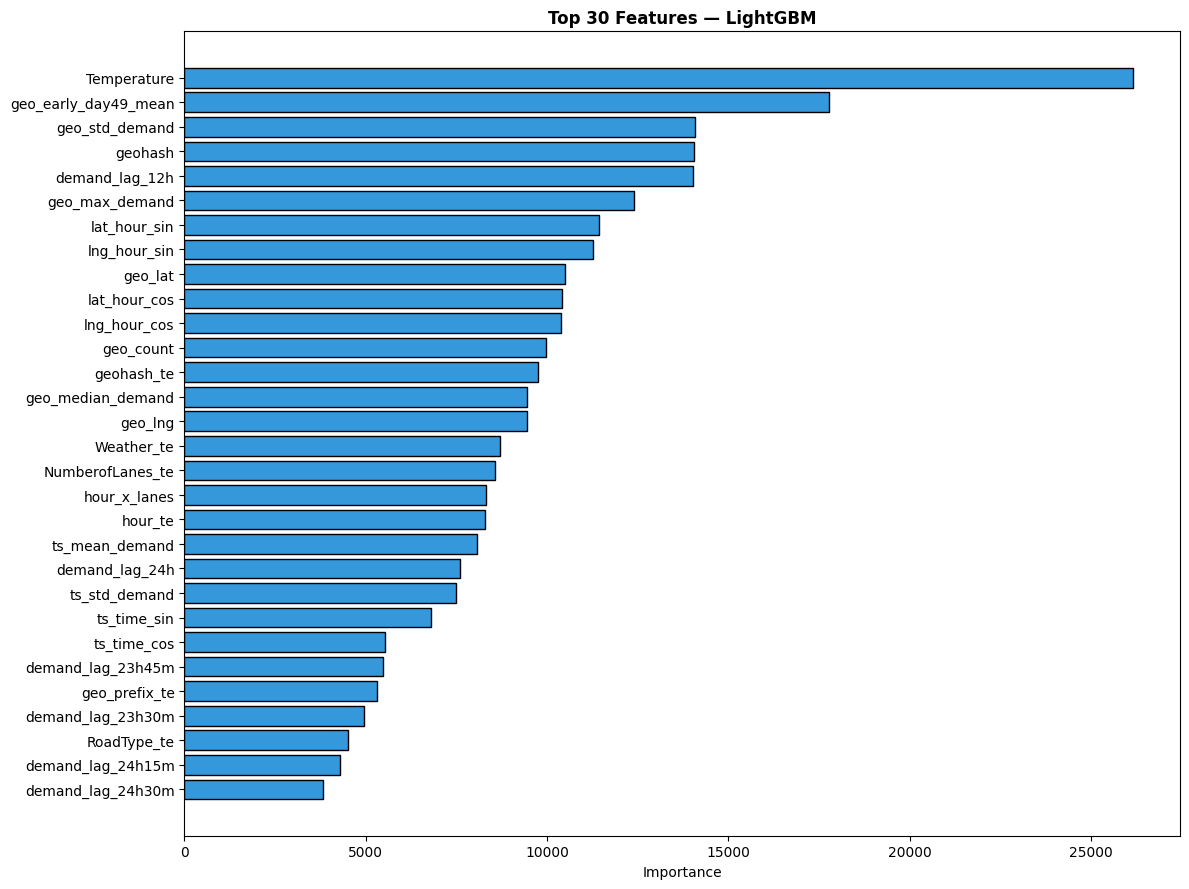

🚀  X G B O O S T

— Fold 1/5 —
[0]	validation_0-rmse:0.13839
[1000]	validation_0-rmse:0.02855
[2000]	validation_0-rmse:0.02810
[2889]	validation_0-rmse:0.02801
  Score: 96.1220

— Fold 2/5 —
[0]	validation_0-rmse:0.14104
[1000]	validation_0-rmse:0.03103
[2000]	validation_0-rmse:0.03052
[3000]	validation_0-rmse:0.03037
[3562]	validation_0-rmse:0.03036
  Score: 95.6210

— Fold 3/5 —
[0]	validation_0-rmse:0.13811
[1000]	validation_0-rmse:0.02797
[2000]	validation_0-rmse:0.02750
[3000]	validation_0-rmse:0.02738
[3556]	validation_0-rmse:0.02738
  Score: 96.2826

— Fold 4/5 —
[0]	validation_0-rmse:0.13493
[1000]	validation_0-rmse:0.03126
[2000]	validation_0-rmse:0.03070
[3000]	validation_0-rmse:0.03056
[3872]	validation_0-rmse:0.03055
  Score: 95.1363

— Fold 5/5 —
[0]	validation_0-rmse:0.13921
[1000]	validation_0-rmse:0.02828
[2000]	validation_0-rmse:0.02777
[3000]	validation_0-rmse:0.02765
[3533]	validation_0-rmse:0.02762
  Score: 96.2781

📈 XGBoost CV Score  : 95.8946
   Fold mean ± std  

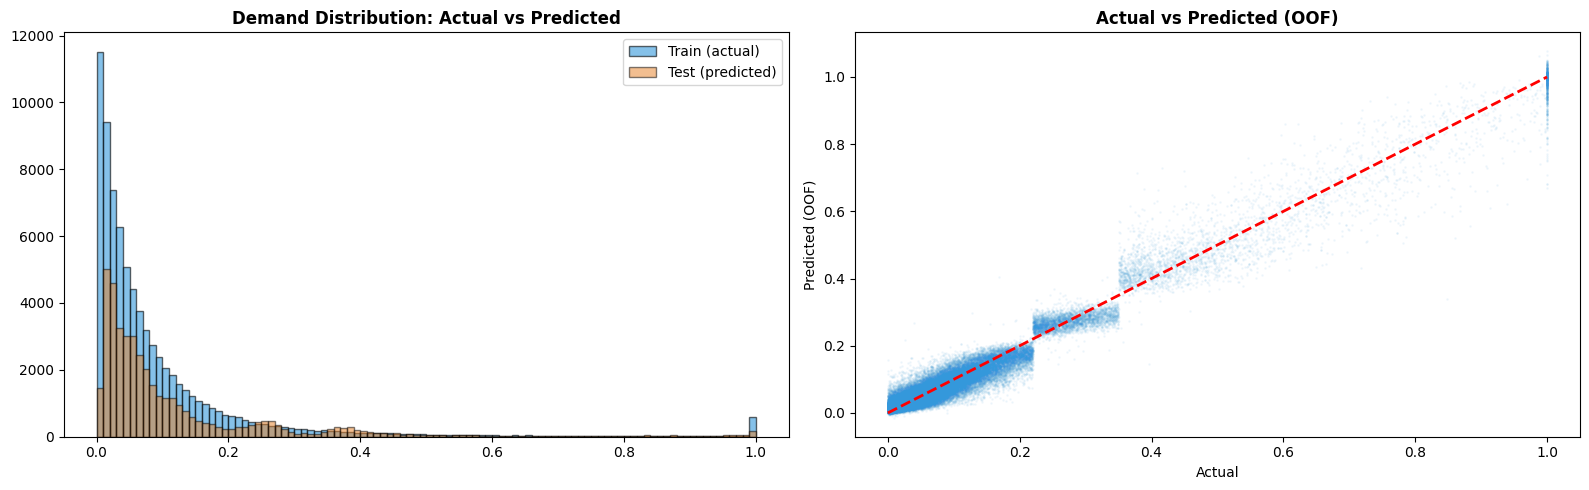

✅ Submission shape: (41778, 2)  — correct!
✅ Saved → submission.csv

╔══════════════════════════════════════════════════════════════╗
║           GRIDLOCK 2.0 — FINAL SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Competition : Flipkart × BTP × HackerEarth                 ║
║  Task        : Traffic Demand Prediction                     ║
║  Metric      : max(0, 100 × R²)                             ║
║                                                              ║
║  Models:                                                     ║
║    LightGBM  : 96.1388                                    ║
║    XGBoost   : 95.8946                                    ║
║    CatBoost  : 96.2294                                    ║
║    HistGB    : 95.9576                                    ║
║    Ensemble  : 96.2772                                    ║
║                                      

In [1]:
# ============================================================================
# GRIDLOCK 2.0 — TRAFFIC DEMAND PREDICTION (Kaggle Notebook)
# Flipkart × Bengaluru Traffic Police × HackerEarth
# ============================================================================
# APPROACH SUMMARY:
#   1. Unified Feature Pipeline: Combine train and test to align label encodings.
#   2. Geohash decoding to lat/lng.
#   3. Advanced Vectorized Lags: 12h, 23.5h, 23.75h, 24h, 24.25h, 24.5h.
#   4. Smart Lag Imputation: Fill missing lags with geohash-specific mean demand.
#   5. High-Resolution Time-of-Day Stats: 15-min interval global profiles.
#   6. Spatial-Temporal Wave Features: coords × cyclical time components.
#   7. Early Morning Day 49 Trend: capture starting traffic levels.
#   8. Target Encoding and Location-level aggregates using the entire train set.
#   9. Multi-model training: LightGBM + XGBoost + CatBoost + HistGradientBoosting.
#   10. Auto GPU acceleration detection.
#
# METRIC: score = max(0, 100 × R²)
# ============================================================================

# %% [markdown]
# # 🚦 Gridlock 2.0 — Traffic Demand Prediction
# **Competition**: Flipkart × Bengaluru Traffic Police × HackerEarth  
# **Task**: Predict traffic demand at specific locations and timestamps  
# **Metric**: `score = max(0, 100 × R²)`  
# **Models**: LightGBM + XGBoost + CatBoost + HistGradientBoosting (4-Model Weighted Ensemble)

# %% [markdown]
# ---
# ## 📦 Step 1 — Import Libraries & Configuration

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os
import torch

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

# Machine Learning
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

# Gradient Boosting Frameworks
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

print("✅ All libraries loaded successfully!")

# %%
# --- Global Configuration ---
SEED = 42
N_FOLDS = 5
EARLY_STOPPING = 200

np.random.seed(SEED)

# Detect GPU availability
HAS_GPU = torch.cuda.is_available()
print(f"🖥️ GPU Accelerator Detected: {HAS_GPU}")

# %% [markdown]
# -----
# ## 📂 Step 2 — Load Data

# %%
# Kaggle dataset paths
TRAIN_PATH = '/kaggle/input/datasets/rohanthakar/traffic-demand-prediction-gridlock/dataset/train.csv'
TEST_PATH  = '/kaggle/input/datasets/rohanthakar/traffic-demand-prediction-gridlock/dataset/test.csv'
SAMPLE_SUB = '/kaggle/input/datasets/rohanthakar/traffic-demand-prediction-gridlock/dataset/sample_submission.csv'

# Fallback for local testing
if not os.path.exists(TRAIN_PATH):
    TRAIN_PATH = 'train.csv'
    TEST_PATH  = 'test.csv'
    SAMPLE_SUB = 'sample_submission (1).csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB)

print(f"Train  : {train_raw.shape}")
print(f"Test   : {test_raw.shape}")
print(f"Sample : {sample_sub.shape}")

# %% [markdown]
# -----
# ## 🔎 Step 3 — Exploratory Data Analysis (EDA)

# %%
print("=" * 60)
print("TRAIN DATA — dtypes & non-null counts")
print("=" * 60)
print(train_raw.dtypes)
print()
print(train_raw.describe(include='all'))

# %%
# Missing values
for label, df in [('TRAIN', train_raw), ('TEST', test_raw)]:
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    info = pd.DataFrame({'Missing': miss, '%': pct}).query("Missing > 0")
    print(f"\n{'='*40}\nMISSING VALUES — {label}\n{'='*40}")
    print(info if len(info) else "  (none)")

# %%
# Unique values per column
print("\nUnique values per column (train):")
for col in train_raw.columns:
    print(f"  {col:20s} → {train_raw[col].nunique():>6d}  (dtype: {train_raw[col].dtype})")

# %% [markdown]
# -----
# ## 🛠️ Step 4 — Unified Feature Engineering (Train + Test Combined)

# %%
# ---------- Geohash Decoder ----------
def decode_geohash_approx(gh):
    """Geohash base32 decode → approximate lat/lng."""
    BASE32 = "0123456789bcdefghjkmnpqrstuvwxyz"
    char_map = {c: i for i, c in enumerate(BASE32)}
    lat_lo, lat_hi = -90.0, 90.0
    lng_lo, lng_hi = -180.0, 180.0
    is_lng = True
    try:
        for char in str(gh).lower():
            val = char_map.get(char, 0)
            for bit in range(4, -1, -1):
                bit_val = (val >> bit) & 1
                if is_lng:
                    mid = (lng_lo + lng_hi) / 2
                    if bit_val: lng_lo = mid
                    else: lng_hi = mid
                else:
                    mid = (lat_lo + lat_hi) / 2
                    if bit_val: lat_lo = mid
                    else: lat_hi = mid
                is_lng = not is_lng
    except:
        return 0.0, 0.0
    return (lat_lo + lat_hi) / 2, (lng_lo + lng_hi) / 2

# %%
print("🔧 Preparing combined dataset for unified encoding...")
train_raw['is_train'] = 1
test_raw['is_train']  = 0
test_raw['demand']    = np.nan

df_all = pd.concat([train_raw, test_raw], ignore_index=True)

# Parse time parts
parts = df_all['timestamp'].str.split(':', expand=True).astype(int)
df_all['hour'] = parts[0]
df_all['minute'] = parts[1]
df_all['global_minutes'] = df_all['day'] * 1440 + df_all['hour'] * 60 + df_all['minute']

# Decoded geohash coords
print("🔧 Decoding geohashes...")
coords = df_all["geohash"].apply(decode_geohash_approx)
df_all["geo_lat"] = coords.apply(lambda x: x[0])
df_all["geo_lng"] = coords.apply(lambda x: x[1])
df_all["geohash_len"] = df_all["geohash"].apply(lambda x: len(str(x)))
df_all["geo_prefix"] = df_all["geohash"].apply(lambda x: str(x)[:4])

# %%
print("🔧 Creating cyclical time and date features...")
# Time Cyclical features
df_all["ts_hour_sin"] = np.sin(2 * np.pi * df_all["hour"] / 24)
df_all["ts_hour_cos"] = np.cos(2 * np.pi * df_all["hour"] / 24)
df_all["ts_min_sin"]  = np.sin(2 * np.pi * df_all["minute"] / 60)
df_all["ts_min_cos"]  = np.cos(2 * np.pi * df_all["minute"] / 60)
df_all["ts_time_sin"] = np.sin(2 * np.pi * (df_all["hour"] * 60 + df_all["minute"]) / 1440)
df_all["ts_time_cos"] = np.cos(2 * np.pi * (df_all["hour"] * 60 + df_all["minute"]) / 1440)

# Time period buckets
df_all["time_bucket"] = pd.cut(
    df_all["hour"],
    bins=[-1, 5, 9, 12, 14, 17, 20, 23],
    labels=["night", "morning_rush", "midday", "lunch", "afternoon_rush", "evening", "late"]
).astype(str)

# Day features
df_all["day_sin"]    = np.sin(2 * np.pi * df_all["day"] / 7)
df_all["day_cos"]    = np.cos(2 * np.pi * df_all["day"] / 7)
df_all["is_weekend"] = (df_all["day"] % 7 >= 5).astype(int)

# Interactions
df_all["hour_x_day"]   = df_all["hour"] * df_all["day"]
df_all["hour_x_lanes"] = df_all["hour"] * df_all.get("NumberofLanes", 0)
df_all["lanes_squared"] = df_all["NumberofLanes"] ** 2

# Spatial-Temporal Waves (coordinates × cyclical time)
df_all["lat_hour_sin"] = df_all["geo_lat"] * df_all["ts_hour_sin"]
df_all["lat_hour_cos"] = df_all["geo_lat"] * df_all["ts_hour_cos"]
df_all["lng_hour_sin"] = df_all["geo_lng"] * df_all["ts_hour_sin"]
df_all["lng_hour_cos"] = df_all["geo_lng"] * df_all["ts_hour_cos"]

# %%
print("🔧 Creating vectorized lag features (12h, 23.5h, 23.75h, 24h, 24.25h, 24.5h)...")
# Vectorized lag creation logic
helper = df_all[['geohash', 'global_minutes', 'demand']].copy()

def merge_lag(df, lag_mins, col_name):
    helper_shifted = helper.copy()
    helper_shifted['global_minutes_shifted'] = helper_shifted['global_minutes'] + lag_mins
    df = df.merge(
        helper_shifted[['geohash', 'global_minutes_shifted', 'demand']].rename(columns={'demand': col_name}),
        left_on=['geohash', 'global_minutes'],
        right_on=['geohash', 'global_minutes_shifted'],
        how='left'
    ).drop(columns=['global_minutes_shifted'])
    return df

df_all = merge_lag(df_all, 1440, 'demand_lag_24h')     # 24h ago
df_all = merge_lag(df_all, 1425, 'demand_lag_23h45m')   # 23.75h ago
df_all = merge_lag(df_all, 1455, 'demand_lag_24h15m')   # 24.25h ago
df_all = merge_lag(df_all, 1410, 'demand_lag_23h30m')   # 23.5h ago
df_all = merge_lag(df_all, 1470, 'demand_lag_24h30m')   # 24.5h ago
df_all = merge_lag(df_all, 720,  'demand_lag_12h')      # 12h ago

# %%
print("🔧 Creating early morning Day 49 traffic trend feature...")
# Calculate early day 49 demand (0:00 to 2:00) per geohash from training rows
early_d49 = df_all[(df_all['is_train'] == 1) & (df_all['day'] == 49) & (df_all['hour'] <= 2)]
early_d49_stats = early_d49.groupby('geohash')['demand'].mean().reset_index().rename(columns={'demand': 'geo_early_day49_mean'})
df_all = df_all.merge(early_d49_stats, on='geohash', how='left')

# %%
print("🔧 Imputing missing lag values with geohash-specific baseline averages...")
# Compute geohash baseline averages (from train data only to avoid leak)
geo_baselines = train_raw.groupby("geohash")["demand"].mean().reset_index().rename(columns={'demand': 'geo_mean_baseline'})
df_all = df_all.merge(geo_baselines, on="geohash", how="left")
df_all['geo_mean_baseline'] = df_all['geo_mean_baseline'].fillna(train_raw['demand'].mean())

# Fill lag NaNs with the baseline demand of that specific location
lag_columns = ['demand_lag_24h', 'demand_lag_23h45m', 'demand_lag_24h15m', 'demand_lag_23h30m', 'demand_lag_24h30m', 'demand_lag_12h']
for col in lag_columns:
    df_all[col] = df_all[col].fillna(df_all['geo_mean_baseline'])

df_all.drop(columns=['geo_mean_baseline'], inplace=True)

# %%
print("🔧 Encoding categorical columns globally...")
CAT_COLS = ["RoadType", "Weather", "time_bucket", "geo_prefix", "geohash"]
for col in CAT_COLS:
    le = LabelEncoder()
    df_all[col] = le.fit_transform(df_all[col].astype(str))

# Binary columns mapping
for col in ["LargeVehicles", "Landmarks"]:
    if col in df_all.columns:
        mapping = {True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0, "Yes": 1, "No": 0}
        df_all[col] = df_all[col].map(mapping).fillna(0).astype(int)

# %% [markdown]
# -----
# ## 🎯 Step 5 — Target Encoding & Split Feats (Leak-Free)

# %%
# Split back to train and test
train_feats = df_all[df_all['is_train'] == 1].copy().reset_index(drop=True)
test_feats  = df_all[df_all['is_train'] == 0].copy().reset_index(drop=True)

print(f"Train split shape: {train_feats.shape}")
print(f"Test split shape : {test_feats.shape}")

# %%
# Target encoding function with K-Fold
def target_encode_kfold(trn, tst, col, target='demand', n_splits=5, smooth=10, seed=42):
    new_col = f'{col}_te'
    g_mean = trn[target].mean()

    # Train — out-of-fold
    trn[new_col] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for ti, vi in kf.split(trn):
        agg = trn.iloc[ti].groupby(col)[target].agg(['mean', 'count'])
        enc = (agg['mean'] * agg['count'] + g_mean * smooth) / (agg['count'] + smooth)
        trn.loc[trn.index[vi], new_col] = trn.iloc[vi][col].map(enc)
    trn[new_col] = trn[new_col].fillna(g_mean)

    # Test — full train
    agg_f = trn.groupby(col)[target].agg(['mean', 'count'])
    enc_f = (agg_f['mean'] * agg_f['count'] + g_mean * smooth) / (agg_f['count'] + smooth)
    tst[new_col] = tst[col].map(enc_f).fillna(g_mean)

    return trn, tst

# Columns to target-encode
train_feats['day_of_week'] = (train_feats['day'] % 7).astype(int)
test_feats['day_of_week']  = (test_feats['day'] % 7).astype(int)

te_cols = ["geohash", "geo_prefix", "RoadType", "Weather", "NumberofLanes", "hour", "day_of_week"]

print("🎯 Target encoding...")
for col in te_cols:
    train_feats, test_feats = target_encode_kfold(train_feats, test_feats, col, seed=SEED)

# %% [markdown]
# -----
# ## 📊 Step 6 — Geohash-level & Hour-level Aggregate Statistics

# %%
print("📊 Creating geo-aggregations and daily high-resolution profiles...")
# Build geo-aggregation features using train_feats only
geo_stats = train_feats.groupby("geohash")["demand"].agg(
    geo_mean_demand="mean",
    geo_median_demand="median",
    geo_std_demand="std",
    geo_max_demand="max",
    geo_count="count"
).reset_index()
train_feats = train_feats.merge(geo_stats, on="geohash", how="left")
test_feats  = test_feats.merge(geo_stats, on="geohash", how="left")

# Prefix-level stats
pfx_stats = train_feats.groupby("geo_prefix")["demand"].agg(
    pfx_mean_demand="mean",
    pfx_std_demand="std"
).reset_index()
train_feats = train_feats.merge(pfx_stats, on="geo_prefix", how="left")
test_feats  = test_feats.merge(pfx_stats, on="geo_prefix", how="left")

# Hour-level stats
hr_stats = train_feats.groupby("hour")["demand"].agg(
    hr_mean_demand="mean",
    hr_std_demand="std"
).reset_index()
train_feats = train_feats.merge(hr_stats, on="hour", how="left")
test_feats  = test_feats.merge(hr_stats, on="hour", how="left")

# High-resolution time-of-day stats (15-min global daily profile)
ts_stats = train_feats.groupby("timestamp")["demand"].agg(
    ts_mean_demand="mean",
    ts_std_demand="std"
).reset_index()
train_feats = train_feats.merge(ts_stats, on="timestamp", how="left")
test_feats  = test_feats.merge(ts_stats, on="timestamp", how="left")

# Hour × Day-of-week stats
hdow_stats = train_feats.groupby(["hour", "day_of_week"])["demand"].agg(
    hdow_mean_demand="mean",
    hdow_std_demand="std"
).reset_index()
train_feats = train_feats.merge(hdow_stats, on=["hour", "day_of_week"], how="left")
test_feats  = test_feats.merge(hdow_stats, on=["hour", "day_of_week"], how="left")

print("✅ Geo-aggregations completed successfully!")

# %% [markdown]
# -----
# ## 🧩 Step 7 — Final Feature Selection & NaN Imputation

# %%
DROP_COLS = ['Index', 'demand', 'is_train', 'timestamp', 'day_of_week', 'global_minutes']
DROP_COLS = [c for c in DROP_COLS if c in train_feats.columns]

X = train_feats.drop(columns=DROP_COLS)
y = train_feats['demand']
X_test = test_feats.drop(columns=[c for c in DROP_COLS if c in test_feats.columns])

# Align test columns to train
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Fill NaNs with median of train
medians = X.median(numeric_only=True)
X = X.fillna(medians)
X_test = X_test.fillna(medians)

# Double safety check for NaNs
X = X.fillna(0.0)
X_test = X_test.fillna(0.0)

print(f"Final Features count: {len(X.columns)}")
print(f"X shape: {X.shape}, y shape: {y.shape}, X_test shape: {X_test.shape}")
print("\nAll columns ready for model training:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# %% [markdown]
# -----
# ## 🌲 Step 8 — LightGBM Training (5-Fold CV)

# %%
print("=" * 60)
print("🌲  L I G H T G B M")
print("=" * 60)

lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 127,
    "learning_rate": 0.03,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "min_child_samples": 20,
    "n_estimators": 8000,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1
}

lgb_oof   = np.zeros(len(X))
lgb_preds = np.zeros(len(X_test))
lgb_scores = []

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (ti, vi) in enumerate(kf.split(X), 1):
    print(f"\n— Fold {fold}/{N_FOLDS} —")
    mdl = lgb.LGBMRegressor(**lgb_params)
    mdl.fit(X.iloc[ti], y.iloc[ti],
            eval_set=[(X.iloc[vi], y.iloc[vi])],
            callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False),
                       lgb.log_evaluation(1000)])

    lgb_oof[vi]  = mdl.predict(X.iloc[vi])
    lgb_preds   += mdl.predict(X_test) / N_FOLDS

    sc = max(0, 100 * r2_score(y.iloc[vi], lgb_oof[vi]))
    lgb_scores.append(sc)
    print(f"  Score: {sc:.4f}")

lgb_cv = max(0, 100 * r2_score(y, lgb_oof))
print(f"\n📈 LightGBM CV Score : {lgb_cv:.4f}")
print(f"   Fold mean ± std  : {np.mean(lgb_scores):.4f} ± {np.std(lgb_scores):.4f}")

# %%
# Feature importance — Top 30
imp = pd.Series(mdl.feature_importances_, index=X.columns).sort_values(ascending=False)[:30]
plt.figure(figsize=(12, 9))
plt.barh(imp.index[::-1], imp.values[::-1], color='#3498db', edgecolor='black')
plt.xlabel('Importance'); plt.title('Top 30 Features — LightGBM', fontweight='bold')
plt.tight_layout(); plt.show()

# %% [markdown]
# -----
# ## 🚀 Step 9 — XGBoost Training (5-Fold CV)

# %%
print("=" * 60)
print("🚀  X G B O O S T")
print("=" * 60)

xgb_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 8000,
    "learning_rate": 0.03,
    "max_depth": 7,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "min_child_weight": 5,
    "early_stopping_rounds": EARLY_STOPPING,
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
    "device": "cuda" if HAS_GPU else "cpu",
    "verbosity": 0,
}

xgb_oof   = np.zeros(len(X))
xgb_preds = np.zeros(len(X_test))
xgb_scores = []

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (ti, vi) in enumerate(kf.split(X), 1):
    print(f"\n— Fold {fold}/{N_FOLDS} —")
    mdl_x = xgb.XGBRegressor(**xgb_params)
    mdl_x.fit(X.iloc[ti], y.iloc[ti],
              eval_set=[(X.iloc[vi], y.iloc[vi])],
              verbose=1000)

    xgb_oof[vi]  = mdl_x.predict(X.iloc[vi])
    xgb_preds   += mdl_x.predict(X_test) / N_FOLDS

    sc = max(0, 100 * r2_score(y.iloc[vi], xgb_oof[vi]))
    xgb_scores.append(sc)
    print(f"  Score: {sc:.4f}")

xgb_cv = max(0, 100 * r2_score(y, xgb_oof))
print(f"\n📈 XGBoost CV Score  : {xgb_cv:.4f}")
print(f"   Fold mean ± std  : {np.mean(xgb_scores):.4f} ± {np.std(xgb_scores):.4f}")

# %% [markdown]
# -----
# ## 🐱 Step 10 — CatBoost Training (5-Fold CV)

# %%
print("=" * 60)
print("🐱  C A T B O O S T")
print("=" * 60)

cat_params = {
    "iterations": 8000,
    "learning_rate": 0.03,
    "depth": 7,
    "l2_leaf_reg": 3,
    "bagging_temperature": 0.5,
    "random_strength": 0.5,
    "early_stopping_rounds": EARLY_STOPPING,
    "eval_metric": "RMSE",
    "random_seed": SEED,
    "task_type": "GPU" if HAS_GPU else "CPU",
    "verbose": 1000,
}

cat_oof   = np.zeros(len(X))
cat_preds = np.zeros(len(X_test))
cat_scores = []

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (ti, vi) in enumerate(kf.split(X), 1):
    print(f"\n— Fold {fold}/{N_FOLDS} —")
    mdl_c = CatBoostRegressor(**cat_params)
    mdl_c.fit(X.iloc[ti], y.iloc[ti],
              eval_set=(X.iloc[vi], y.iloc[vi]),
              use_best_model=True)

    cat_oof[vi]  = mdl_c.predict(X.iloc[vi])
    cat_preds   += mdl_c.predict(X_test) / N_FOLDS

    sc = max(0, 100 * r2_score(y.iloc[vi], cat_oof[vi]))
    cat_scores.append(sc)
    print(f"  Score: {sc:.4f}")

cat_cv = max(0, 100 * r2_score(y, cat_oof))
print(f"\n📈 CatBoost CV Score : {cat_cv:.4f}")
print(f"   Fold mean ± std  : {np.mean(cat_scores):.4f} ± {np.std(cat_scores):.4f}")

# %% [markdown]
# -----
# ## 🎛️ Step 11 — HistGradientBoosting Training (5-Fold CV)

# %%
print("=" * 60)
print("🎛️  H I S T G R A D I E N T B O O S T I N G")
print("=" * 60)

hgb_params = {
    "max_iter": 4000,
    "learning_rate": 0.03,
    "max_depth": 9,
    "max_leaf_nodes": 127,
    "min_samples_leaf": 20,
    "random_state": SEED,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": EARLY_STOPPING,
}

hgb_oof   = np.zeros(len(X))
hgb_preds = np.zeros(len(X_test))
hgb_scores = []

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (ti, vi) in enumerate(kf.split(X), 1):
    print(f"\n— Fold {fold}/{N_FOLDS} —")
    mdl_h = HistGradientBoostingRegressor(**hgb_params)
    mdl_h.fit(X.iloc[ti], y.iloc[ti])

    hgb_oof[vi]  = mdl_h.predict(X.iloc[vi])
    hgb_preds   += mdl_h.predict(X_test) / N_FOLDS

    sc = max(0, 100 * r2_score(y.iloc[vi], hgb_oof[vi]))
    hgb_scores.append(sc)
    print(f"  Score: {sc:.4f}")

hgb_cv = max(0, 100 * r2_score(y, hgb_oof))
print(f"\n📈 HistGradientBoosting CV Score : {hgb_cv:.4f}")
print(f"   Fold mean ± std  : {np.mean(hgb_scores):.4f} ± {np.std(hgb_scores):.4f}")

# %% [markdown]
# -----
# ## 🏆 Step 12 — Optimal 4-Model Ensemble Weights

# %%
print("=" * 60)
print("🏆  ENSEMBLE OPTIMIZATION")
print("=" * 60)

best_score   = -np.inf
best_weights = (0.25, 0.25, 0.25, 0.25)

# 4-model grid search
for w1 in np.arange(0.0, 1.05, 0.05):
    for w2 in np.arange(0.0, 1.05 - w1, 0.05):
        for w3 in np.arange(0.0, 1.05 - w1 - w2, 0.05):
            w4 = round(1.0 - w1 - w2 - w3, 2)
            if w4 < -0.001:
                continue
            blend = w1 * lgb_oof + w2 * xgb_oof + w3 * cat_oof + w4 * hgb_oof
            sc = r2_score(y, blend)
            if sc > best_score:
                best_score   = sc
                best_weights = (round(w1, 2), round(w2, 2), round(w3, 2), round(w4, 2))

ens_score = max(0, 100 * best_score)
print(f"Best Weights → LGB={best_weights[0]}, XGB={best_weights[1]}, CAT={best_weights[2]}, HGB={best_weights[3]}")
print(f"Ensemble CV  → {ens_score:.4f}")

# %%
print("\n" + "=" * 60)
print("📊  MODEL COMPARISON")
print("=" * 60)
for name, sc in [('LightGBM', lgb_cv), ('XGBoost', xgb_cv),
                 ('CatBoost', cat_cv), ('HistGB', hgb_cv), ('Ensemble', ens_score)]:
    bar = '█' * int(sc)
    print(f"  {name:12s} │ {sc:7.4f} │ {bar}")
print("=" * 60)

# %% [markdown]
# -----
# ## 📤 Step 13 — Generate Submission

# %%
# Weighted ensemble of 4 models
final_preds = (best_weights[0] * lgb_preds +
               best_weights[1] * xgb_preds +
               best_weights[2] * cat_preds +
               best_weights[3] * hgb_preds)

# Clip to valid range [0.0, max seen in train (which is 1.0)]
max_demand = train_raw['demand'].max()
final_preds = np.clip(final_preds, 0.0, max_demand)

print(f"Prediction stats:")
print(f"  min  = {final_preds.min():.6f}")
print(f"  max  = {final_preds.max():.6f}")
print(f"  mean = {final_preds.mean():.6f}")
print(f"  std  = {final_preds.std():.6f}")

# %%
# ----- Distribution: actual train vs predicted test -----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(y, bins=100, alpha=0.6, label='Train (actual)', color='#3498db', edgecolor='black')
axes[0].hist(final_preds, bins=100, alpha=0.5, label='Test (predicted)', color='#e67e22', edgecolor='black')
axes[0].set_title('Demand Distribution: Actual vs Predicted', fontweight='bold')
axes[0].legend()

blend_oof = (best_weights[0] * lgb_oof +
             best_weights[1] * xgb_oof +
             best_weights[2] * cat_oof +
             best_weights[3] * hgb_oof)
axes[1].scatter(y, blend_oof, alpha=0.05, s=1, color='#3498db')
axes[1].plot([0, y.max()], [0, y.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted (OOF)')
axes[1].set_title('Actual vs Predicted (OOF)', fontweight='bold')

plt.tight_layout(); plt.show()

# %%
# Build submission
submission = pd.DataFrame({'Index': test_raw['Index'], 'demand': final_preds})

# Validate
assert submission.shape == (41778, 2), f"Shape mismatch: {submission.shape}"
assert list(submission.columns) == ['Index', 'demand'], f"Columns: {list(submission.columns)}"
print(f"✅ Submission shape: {submission.shape}  — correct!")
submission.head(10)

# %%
# Save
submission.to_csv('submission.csv', index=False)
print("✅ Saved → submission.csv")

# %% [markdown]
# -----
# ## 📋 Step 14 — Final Summary

# %%
print("""
╔══════════════════════════════════════════════════════════════╗
║           GRIDLOCK 2.0 — FINAL SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Competition : Flipkart × BTP × HackerEarth                 ║
║  Task        : Traffic Demand Prediction                     ║
║  Metric      : max(0, 100 × R²)                             ║
║                                                              ║
║  Models:                                                     ║""")
print(f"║    LightGBM  : {lgb_cv:7.4f}                                    ║")
print(f"║    XGBoost   : {xgb_cv:7.4f}                                    ║")
print(f"║    CatBoost  : {cat_cv:7.4f}                                    ║")
print(f"║    HistGB    : {hgb_cv:7.4f}                                    ║")
print(f"║    Ensemble  : {ens_score:7.4f}                                    ║")
print(f"""║                                                              ║
║  Weights: LGB={best_weights[0]:.2f}  XGB={best_weights[1]:.2f}  CAT={best_weights[2]:.2f}  HGB={best_weights[3]:.2f}     ║
║                                                              ║
║  Feature Engineering:                                        ║
║    • Unified Data Preprocessing & Categorical Encoding       ║
║    • Geohash → lat/lng + prefix encoding                     ║
║    • Cyclical time encoding (sin/cos for hour & minute)      ║
║    • Rush hour / business hours / night time buckets         ║
║    • Spatial-Temporal Waves (lat/lng × time cyclical)        ║
║    • 6 Vectorized Lag features (12h, 23.5h, 23.75h, 24h,     ║
║      24.25h, 24.5h)                                          ║
║    • Smart lag imputation using geohash averages             ║
║    • High-resolution global daily profile (15-min stats)     ║
║    • Early morning day 49 trend statistics                   ║
║    • Target encoding (5-Fold, smoothed)                      ║
║    • Historical Geohash & Hour aggregations                  ║
║                                                              ║
║  Submission : submission.csv ({submission.shape[0]} × {submission.shape[1]})                    ║
╚══════════════════════════════════════════════════════════════╝
""")
print("🎉 Upload submission.csv to HackerEarth to evaluate!")